# Serialise Detections to a JSON File

---

[![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Child-pi/supervision/blob/develop/docs/notebooks/serialise-detections-to-json.ipynb)

This cookbook introduces the [sv.JSONSink](https://supervision.roboflow.com/develop/detection/tools/save_detections/#supervision.detection.tools.json_sink.JSONSink) tool designed to write captured object detection data to file from video streams/file.

Click the `Open in Colab` button to run the cookbook on Google Colab.

In [1]:
# Clean up legacy inference package if present in the Colab session
!pip uninstall -y -q inference roboflow-workflows 2>/dev/null || true
!pip install -q rfdetr supervision trackers pandas tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 602.7/602.7 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.0/385.0 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.8/220.8 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 8.6 MB/s eta 0:00:00


In [2]:
import json
from collections import defaultdict
from typing import List

import numpy as np
import pandas as pd
from rfdetr import RFDETRSmall
import supervision as sv
from supervision.assets import VideoAssets, download_assets
from tqdm import tqdm
from trackers import ByteTrackTracker


The parameters defined below are:
* `SOURCE_VIDEO_PATH` - the path to the input video
* `CONFIDENCE_THRESHOLD` - do not include detections below this confidence level
* `FILE_NAME` - write the JSON output to this file


In [3]:
SOURCE_VIDEO_PATH = download_assets(VideoAssets.PEOPLE_WALKING)
CONFIDENCE_THRESHOLD = 0.3
FILE_NAME = "detections.json"


[2026-09-19 12:50:52] [INFO] supervision.assets.downloader - Downloading people-walking.mp4 assets


  0%|          | 0/7606633 [00:00<?, ?it/s]

As a result of executing the above `download_assets(VideoAssets.PEOPLE_WALKING)` , you will download a video file and save it at the `SOURCE_VIDEO_PATH`. Keep in mind that the video preview below works only in the web version of the cookbooks and not in Google Colab.

<video controls width="1280">
  <source src="https://media.roboflow.com/supervision/video-examples/people-walking.mp4" type="video/mp4">
</video>


## Read single frame from video

The [`get_video_frames_generator`](https://supervision.roboflow.com/develop/utils/video/#supervision.utils.video.get_video_frames_generator) enables us to easily iterate over video frames. Let's create a video generator for our sample input file and display its first frame on the screen.


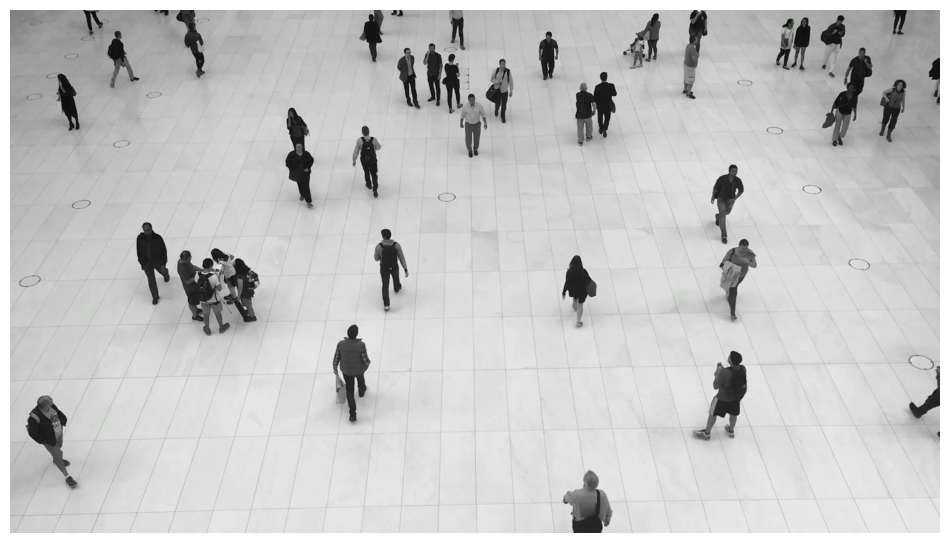

In [4]:
generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(generator)

sv.plot_image(frame, (12, 12))


We can also use [`VideoInfo.from_video_path`](https://supervision.roboflow.com/develop/utils/video/#supervision.utils.video.VideoInfo) to learn basic information about our video, such as duration, resolution, or FPS.

In [5]:
sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)


VideoInfo(width=1920, height=1080, fps=25.0, total_frames=341)

## Initialize ByteTrackTracker

[ByteTrackTracker](https://trackers.roboflow.com/latest/) is a multi-object tracking algorithm from the external `trackers` package. It tracks and links detected objects across multiple frames, providing consistent IDs for each object. Initialize the `ByteTrackTracker` object.

In [6]:
byte_track = ByteTrackTracker(
    minimum_consecutive_frames=3, track_activation_threshold=CONFIDENCE_THRESHOLD
)
byte_track.reset()


## Process video and save detections to JSON file

To save detections to a JSON file, we use [`sv.JSONSink`](https://supervision.roboflow.com/latest/how_to/save_detections/#save-detections-as-json). We iterate over the video frames using [`sv.get_video_frames_generator`](https://supervision.roboflow.com/develop/utils/video/#supervision.utils.video.get_video_frames_generator), run object detection using `RFDETRSmall`, maintain persistent object IDs using `ByteTrackTracker`, and append detections along with custom metadata like `frame_number` to `json_sink`.

In [7]:
model = RFDETRSmall()
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)

with sv.JSONSink(FILE_NAME) as json_sink:
    for frame_number, frame in enumerate(tqdm(generator, total=video_info.total_frames)):
        # Model prediction: convert BGR frame to RGB
        detections = model.predict(frame[:, :, ::-1].copy(), threshold=CONFIDENCE_THRESHOLD)

        # Filter for person detections
        detections = detections[detections.data["class_name"] == "person"]

        # Update tracking IDs
        detections = byte_track.update(detections)
        detections = detections[detections.tracker_id != -1]

        # Write detections to JSON sink
        json_sink.append(detections, custom_data={"frame_number": frame_number})


[2026-09-19 12:50:53] [INFO] rf-detr - Downloading pretrained weights for /root/.roboflow/models/rf-detr-small.pth


/root/.roboflow/models/rf-detr-small.pth:   0%|          | 0.00/368M [00:00<?, ?iB/s]

[2026-09-19 12:51:05] [INFO] rf-detr - MD5 validation successful for /root/.roboflow/models/rf-detr-small.pth


[2026-09-19 12:51:05] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-19 12:51:05] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-19 12:51:06] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-small.pth already exists with correct MD5 hash.


100%|██████████| 341/341 [00:24<00:00, 14.04it/s]


## Visualize results of detections JSON data with Pandas

Let's inspect our resulting data using Pandas.


In [8]:
df = pd.read_json(FILE_NAME)
df


,x_min,y_min,x_max,y_max,class_id,confidence,tracker_id,source_shape,class_name,frame_number
0,1143.499390,937.545349,1243.923096,1079.193604,1,0.860402,0,"[1080, 1920]",person,2
1,1396.074463,703.574646,1517.276123,888.262939,1,0.781177,1,"[1080, 1920]",person,2
2,672.892639,636.065063,747.167419,833.612244,1,0.778270,2,"[1080, 1920]",person,2
3,710.808472,231.644562,766.612671,373.226837,1,0.637207,3,"[1080, 1920]",person,2
4,1142.997803,496.830872,1208.791504,645.260254,1,0.679890,4,"[1080, 1920]",person,2
...,...,...,...,...,...,...,...,...,...,...
4943,1278.057495,4.510066,1328.205078,128.093521,1,0.408175,14,"[1080, 1920]",person,340
4944,749.589844,95.773819,800.390869,247.062347,1,0.514880,15,"[1080, 1920]",person,340
4945,1869.192871,712.079834,1919.877441,835.343445,1,0.355382,24,"[1080, 1920]",person,340
4946,385.556000,470.709808,460.504791,634.939331,1,0.454012,26,"[1080, 1920]",person,340


## Convert JSON data to sv.Detections

We can parse the serialised JSON rows back into `sv.Detections` objects grouped by frame.

In [9]:
def json_to_detections(json_file: str) -> List[sv.Detections]:
    rows_by_frame_number = defaultdict(list)
    with open(json_file, "r") as f:
        data = json.load(f)
    for row in data:
        frame_number = int(row["frame_number"])
        rows_by_frame_number[frame_number].append(row)

    detections_list = []
    for frame_number, rows in rows_by_frame_number.items():
        xyxy = []
        class_id = []
        confidence = []
        tracker_id = []
        custom_data = defaultdict(list)

        for row in rows:
            xyxy.append([float(row[key]) for key in ["x_min", "y_min", "x_max", "y_max"]])
            class_id.append(int(row["class_id"]) if row["class_id"] is not None and row["class_id"] != "" else 0)
            confidence.append(float(row["confidence"]) if row["confidence"] is not None and row["confidence"] != "" else 1.0)
            tracker_id.append(int(row["tracker_id"]) if row["tracker_id"] is not None and row["tracker_id"] != "" else -1)

            for custom_key in row.keys():
                if custom_key in ["x_min", "y_min", "x_max", "y_max", "class_id", "confidence", "tracker_id"]:
                    continue
                custom_data[custom_key].append(row[custom_key])

        detections_list.append(
            sv.Detections(
                xyxy=np.array(xyxy, dtype=np.float32),
                class_id=np.array(class_id, dtype=int),
                confidence=np.array(confidence, dtype=np.float32),
                tracker_id=np.array(tracker_id, dtype=int),
                data=dict(custom_data)
            )
        )

    return detections_list


In [10]:
detections_list = json_to_detections(FILE_NAME)

print(f"Frames with detections: {len(detections_list)}")
print(detections_list[0])


Frames with detections: 339
Detections(xyxy=array([[1143.4994 ,  937.54535, 1243.9231 , 1079.1936 ],
       [1396.0745 ,  703.57465, 1517.2761 ,  888.26294],
       [ 672.89264,  636.06506,  747.1674 ,  833.61224],
       [ 710.8085 ,  231.64456,  766.6127 ,  373.22684],
       [1142.9978 ,  496.83087, 1208.7915 ,  645.26025],
       [1454.0908 ,  324.52994, 1520.943  ,  485.51944],
       [ 755.9701 ,  442.5064 ,  828.54724,  615.23456],
       [ 569.52765,  275.44855,  631.52203,  419.06003],
       [1467.3357 ,  480.8608 , 1544.177  ,  651.1001 ],
       [  35.28594,  800.42725,  142.95982,  991.2527 ],
       [ 257.41296,  443.6699 ,  328.26694,  611.1366 ]], dtype=float32), mask=None, confidence=array([0.86040175, 0.7811768 , 0.77827007, 0.6372066 , 0.6798899 ,
       0.6661997 , 0.7201503 , 0.6229164 , 0.68391913, 0.6068681 ,
       0.58414304], dtype=float32), class_id=array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]), tracker_id=array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]), data=

### Annotate Frame

Visualize frame 100 alongside the detections loaded from the JSON file.

In [11]:
FRAME_NUMBER = 100

detections = detections_list[FRAME_NUMBER]
frame_number = int(detections.data["frame_number"][0])

generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, start=frame_number)
frame = next(generator)


### Annotate Image with Detections

Finally, we annotate the frame with [`sv.BoxAnnotator`](https://supervision.roboflow.com/latest/detection/annotators/#supervision.annotators.core.BoxAnnotator) and [`sv.LabelAnnotator`](https://supervision.roboflow.com/latest/detection/annotators/#supervision.annotators.core.LabelAnnotator).

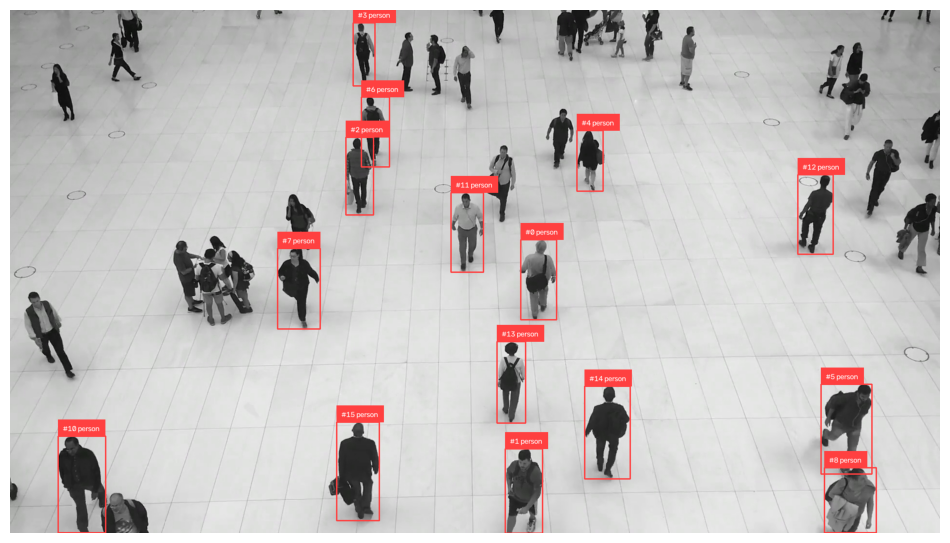

In [12]:
bounding_box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

labels = [
    f"#{tracker_id} {class_name}"
    for tracker_id, class_name in zip(detections.tracker_id, detections.data["class_name"])
]

annotated_frame = frame.copy()
annotated_frame = bounding_box_annotator.annotate(scene=annotated_frame, detections=detections)
annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=detections, labels=labels)
sv.plot_image(annotated_frame, (12, 12))


## References 📚

* Supervision: https://supervision.roboflow.com
* sv.Detections: https://supervision.roboflow.com/develop/detection/core/#detections
* Save Detections to JSON: https://supervision.roboflow.com/develop/how_to/save_detections/#save-detections-as-json
* Custom fields: https://supervision.roboflow.com/develop/how_to/save_detections/#custom-fields
* ByteTrack (external `trackers` package): https://trackers.roboflow.com/latest/
* RF-DETR: https://github.com/roboflow/rf-detr
